In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)
%cd '/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC'

Mounted at /content/drive
/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC


In [2]:
import pandas as pd
import torch

In [3]:
# Exploring dataset
df = pd.read_csv('nfl_combine_2000_2020.csv')
df = df.dropna(subset=['wAVOE'])
df.columns

Index(['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St',
       'wAV', 'DrAV', 'G', 'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD',
       'Pass_Int', 'Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rec', 'Rec_Yds',
       'Rec_TD', 'Solo', 'Def_Int', 'Sk', 'College/Univ', 'Misc', 'pfref_id',
       'Season', 'wAVOE', 'PosGroup', '40yd', 'Vertical', 'Broad Jump', 'Cone',
       'Shuttle', 'Wt', 'BroadJump'],
      dtype='object')

In [4]:
# FEATURES AND TARGETS

# Features - pick rounds, exact overall pick number, and age
# Cell 3 — replace feature definition
feature_cols = ['Rnd', 'Pick', 'Age']
X = df[feature_cols].fillna(df[feature_cols].median()).values  # median impute missing combine

X_scaled = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
X = torch.tensor(X_scaled, dtype=torch.float32)

# Position encoding
df['Pos_idx'], pos_map = pd.factorize(df['Pos'])
pos_idx = df['Pos_idx'].values
num_positions = len(pos_map)

# Lookup Table - for confusion purposes
mapping_df = pd.DataFrame({
    'Code': range(len(pos_map)),
    'Position': pos_map
})

# Regression target - continuous number, predict "how much" or "how many"
y_reg = df['wAVOE'].values

# Classification target (top 30% = hit) - label, predict "which one" or "yes/no"
threshold = df['wAVOE'].quantile(0.7) # top 30%
df['y_cls'] = (df['wAVOE'] > threshold).astype(int)
y_cls = df['y_cls'].values

# Convert to tensors - PyTorch or TensorFlow built to speak that language
X_scaled = (X - X.mean(axis = 0)) / (X.std(axis = 0) + 1e-8) # 1e-8: prevents code from crashing when trying to divide by 0
X = torch.tensor(X_scaled, dtype=torch.float32)
pos_idx = torch.tensor(pos_idx, dtype = torch.long)

/tmp/ipykernel_6146/4229750133.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X_scaled, dtype=torch.float32)


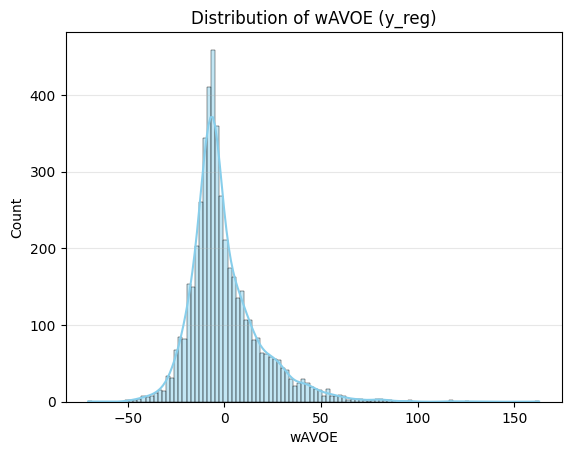

In [5]:
# Distribution of wAVOE
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['wAVOE'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of wAVOE (y_reg)')
plt.grid(axis='y', alpha=0.3)

In [6]:
# FiLM Generator - Feature-wise Linear Modulation

import torch.nn as nn

class FiLMGenerator(nn.Module): # tuner to change scale and baseline of data
  """
  # self: self
  # num_positions: total # of unique positions
  # emb_dim: how many numbers the model uses to describe a single position (turns into vector of numbers, allowing the model to learn that some positions are similar)
  # hidden_dim: neurons in the middle layers of network (higher number allows model to learn more complex relationships, careful of overfitting)
  """
  def __init__(self, num_positions, emb_dim, hidden_dim): # __init__ runs automatically each time a new object(instance) of that class is created
    super().__init__() # turns FiLMGenerator into a live component that can talk to other neural network layers

    # self.name
    self.embedding = nn.Embedding(num_positions, emb_dim) # creates lookup table

    self.mlp = nn.Sequential(
        nn.Linear(emb_dim, hidden_dim), # takes position and looks for initial patterns
        nn.ReLU(), # turns all negative numbers to 0 to learn non-linear patterns
        nn.Linear(hidden_dim, 2*hidden_dim) # doubles the size of the data - need two values for each feature for gamma and beta
    )

  def forward(self, pos_idx):
    emb = self.embedding(pos_idx) # grabs the numbers of the position
    gamma_beta = self.mlp(emb) # runs the numbers through the mini-network
    gamma, beta = gamma_beta.chunk(2, dim = -1) # slices long output vector in half (first half to multiply/scale, second half to add/shift data)

    gamma = gamma.clamp(-5, 5) # prevents gamma and beta becoming very large early in training
    beta = beta.clamp(-5, 5)

    return gamma, beta


In [7]:
# Gated Model (FiLM applied) - good for feature selection

class GatedModel(nn.Module): # light switch - decides how much information to let through
  # input_dim: the number of numeric features (cols) feeding into the model for each player
  def __init__(self, input_dim, hidden_dim, num_positions): # building, only runs once at birth
    super().__init__() # live component

    # fc: fully connected - one layer to the next
    self.fc1 = nn.Linear(input_dim, hidden_dim) # translate raw data into internal language
    self.fc2 = nn.Linear(hidden_dim, hidden_dim) # find complex patterns

    self.film = FiLMGenerator(num_positions, 20, hidden_dim)

    # Two heads
    self.reg_head = nn.Linear(hidden_dim, 1) # predicts continuous
    self.cls_head = nn.Linear(hidden_dim, 1) # predicts category
  # x is the tensor containing the numeric columns identified earlier
  def forward(self, x, pos_idx): # conveyor belt, runs each time we make a prediction
    gamma, beta = self.film(pos_idx)

    h = self.fc1(x)
    h = gamma * h + beta # scale and shift activations by position
    h = torch.relu(h)

    h = self.fc2(h)
    h = gamma * h + beta
    h = torch.relu(h)

    reg_out = self.reg_head(h)
    cls_logits = self.cls_head(h)

    return reg_out, cls_logits

In [8]:
# Loss (with class imbalance)
pos_weight = (y_cls == 0).sum() / (y_cls == 1).sum()
pos_weight = torch.tensor(pos_weight)

loss_fn_reg = nn.MSELoss()
loss_fn_cls = nn.BCEWithLogitsLoss(pos_weight = pos_weight) # values the positive class more

def compute_loss(reg_pred, reg_true, cls_logits, cls_true):
  return (
      loss_fn_reg(reg_pred, reg_true) +
      loss_fn_cls(cls_logits, cls_true)
  )

In [9]:
# Train/Validation
from sklearn.model_selection import train_test_split

X_train, X_val, pos_train, pos_val, yreg_train, yreg_val, ycls_train, ycls_val = train_test_split(
    X, pos_idx, y_reg, y_cls, test_size = .2, random_state = 42
)

# Convert splits to tensor
yreg_train = torch.tensor(yreg_train, dtype=torch.float32).view(-1, 1)
yreg_val   = torch.tensor(yreg_val,   dtype=torch.float32).view(-1, 1)
ycls_train = torch.tensor(ycls_train, dtype=torch.float32).view(-1, 1)
ycls_val   = torch.tensor(ycls_val,   dtype=torch.float32).view(-1, 1)

# Validation MAE
def compute_mae(pred, true):
  return torch.mean(torch.abs(pred - true))

In [10]:
# Initialize model
model = GatedModel(input_dim=9, hidden_dim=64, num_positions=num_positions)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [11]:
# Best model based on validation MAE

best_val_mae = float('inf')

for epoch in range(100):
  model.train() # switches into train mode

  reg_pred, cls_logits = model(X_train, pos_train)
  loss = compute_loss(reg_pred, yreg_train, cls_logits, ycls_train)

  optimizer.zero_grad()
  loss.backward() # how much weight contributed to the total error
  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0) # smoother learning, prevents gradients from exploding
  optimizer.step() # updates parameters

  # Validation - computes MAE to track best model
  model.eval() # switches into eval mode
  with torch.no_grad(): # turn off gradient tracking
    # returns predicted wAVOE (reg_val_pred) and the "Hit" probability scores (cls_val_logits)
    reg_val_pred, cls_val_logits = model(X_val, pos_val) # runs GatedModel forward pass
    val_mae = compute_mae(reg_val_pred, yreg_val) # calculates accuracy of regression

  # Checkpoint
  if val_mae < best_val_mae:
    best_val_mae = val_mae
    torch.save(model.state_dict(), "best_model.pt")

  if epoch % 10 == 0:
    print(f"Epoch {epoch}, Val MAE: {val_mae: .4f}")


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3868x3 and 9x64)

In [ ]:
# Baseline model

class MLPBaseline(nn.Module): # nn.Module is the Base Class
  def __init__(self, input_dim, hidden_dim):
    super().__init__()

    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, hidden_dim)

    self.reg_head = nn.Linear(hidden_dim, 1)
    self.cls_head = nn.Linear(hidden_dim, 1)

  def forward(self, x):
    h = torch.relu(self.fc1(x)) # relu: kill negatives (help learn non-linear, complex logic), self.fc1(x): multiplies features by weights
    h = torch.relu(self.fc2(h))

    reg_out = self.reg_head(h)
    cls_logits = self.cls_head(h)

    return reg_out, cls_logits


In [ ]:
# Training Baseline Model
baseline = MLPBaseline(input_dim=X.shape[1], hidden_dim=64)
optimizer_base = torch.optim.Adam(baseline.parameters(), lr=1e-3)

best_val_mae_base = float('inf')

for epoch in range(100):
    baseline.train()

    reg_pred, cls_logits = baseline(X_train)
    loss = compute_loss(reg_pred, yreg_train, cls_logits, ycls_train)

    optimizer_base.zero_grad()
    loss.backward()
    optimizer_base.step()

    # Validation
    baseline.eval()
    with torch.no_grad():
        reg_val_pred, cls_val_logits = baseline(X_val)
        val_mae = compute_mae(reg_val_pred, yreg_val)

    if val_mae < best_val_mae_base:
        best_val_mae_base = val_mae
        torch.save(baseline.state_dict(), "best_baseline.pt")

    if epoch % 10 == 0:
        print(f"[Baseline] Epoch {epoch}, Val MAE: {val_mae:.4f}")

In [ ]:
# Load and evaluate model and baseline

# Model
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    reg_pred, cls_logits = model(X_val, pos_val)

mae_gated = compute_mae(reg_pred, yreg_val)

probs = torch.sigmoid(cls_logits)
brier_gated = torch.mean((probs - ycls_val) ** 2)

# Baseline
baseline.load_state_dict(torch.load("best_baseline.pt"))
baseline.eval()

with torch.no_grad():
    reg_pred_base, cls_logits_base = baseline(X_val)

mae_base = compute_mae(reg_pred_base, yreg_val)

probs_base = torch.sigmoid(cls_logits_base)
brier_base = torch.mean((probs_base - ycls_val) ** 2)

In [ ]:
# PR-AUC: Precision-Recall Area Under Curve: tells you how good your model is at finding the "Hits" (top 30% of players) without accidentally labeling everyone as a hit
from sklearn.metrics import average_precision_score

pr_auc_gated = average_precision_score(
    ycls_val.detach().cpu().numpy(), # detach from math and cpu brings home from GPU
    probs.detach().cpu().numpy()
)

pr_auc_base = average_precision_score(
    ycls_val.detach().cpu().numpy(),
    probs_base.detach().cpu().numpy()
)

In [ ]:
# Final Comparison:
print("=== FINAL RESULTS ===")

print("\nGATED MODEL")
print("MAE:", mae_gated.item())
print("Brier:", brier_gated.item())
print("PR-AUC:", pr_auc_gated)

print("\nBASELINE MLP")
print("MAE:", mae_base.item())
print("Brier:", brier_base.item())
print("PR-AUC:", pr_auc_base)

The gated FiLM model outperforms the baseline MLP across all three metrics — it predicts wAVOE more accurately (MAE 13.02 vs 13.39), produces better-calibrated hit probabilities (Brier 0.235 vs 0.244), and is meaningfully better at identifying true hits without over-labeling (PR-AUC 0.398 vs 0.378). That said, the margins are modest, which suggests the position-aware FiLM modulation is genuinely adding signal but is being held back by the limited feature set — with only round, pick, and age as inputs, there's a ceiling on how much either model can learn. Adding combine measurables like 40-yard dash, weight, and position-specific drills would likely widen the gap between the two models and give the FiLM architecture more opportunity to show its advantage.